### Import packages

In [2]:

import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
from xgboost import plot_importance
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import plot_tree
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import to_graphviz
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.feature_selection import RFECV,SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, roc_auc_score
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.linear_model import LogisticRegressionCV

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.getcwd()
os.chdir('/content/drive/MyDrive/GTU/DSAN5300/dsan5300_group1_final_project/')

## BNPL1 - Full data

### Data preprocessing

In [74]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_44926/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [75]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL1']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [76]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [77]:
# drop columns
data_cleaned = data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C', # remove original columns due to OHE
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])


In [78]:
# independent variables
X = data_cleaned.drop(columns=['BNPL1'])
# target variable
y = data_cleaned['BNPL1']

# weights
weights = data_cleaned['weight']

In [79]:
# train, test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# resampling train fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test_res = X_test["weight"].values
X_test_res = X_test.drop(columns=["weight"])


In [80]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017"]

scaler = StandardScaler()

X_train_res[numeric_cols] = scaler.fit_transform(X_train_res[numeric_cols])
X_test_res[numeric_cols] = scaler.transform(X_test_res[numeric_cols])

In [12]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(pd.DataFrame([c, X_test_res[c].unique()] for c in X_train_res.columns))
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,0,1
0,EF3_a,"[0, 1]"
1,EF3_b,"[1, 0]"
2,EF3_c,"[0, 1]"
3,EF3_d,"[0, 1]"
4,EF3_e,"[0, 1]"
5,EF3_f,"[0, 1]"
6,EF3_g,"[0, 1]"
7,EF3_h,"[0, 1]"
8,ppage,"[1.5115426878041756, -0.8236387120409172, 0.40..."
9,ppgender,"[1, 0]"


### Build model


In [81]:
# build model
log_reg_cv = LogisticRegressionCV(
    Cs=10, # try 10 different penalty values
    cv=5,
    penalty='l2',
    scoring='roc_auc',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

# fit the model
log_reg_cv.fit(X_train_res, y_train_res)

# display model result with different penalty scores
print(f"Optimal C (Regularization Strength): {log_reg_cv.C_[0]}")

Optimal C (Regularization Strength): 2.782559402207126


In [82]:
# rerun model with optimal regularization strength
final_model = LogisticRegression(
    C=2.782,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [84]:
cv_scores = cross_val_score(
    final_model,
    X_train_res,
    y_train_res,
    cv=5,
    scoring='roc_auc'
)

In [85]:
# fit the mdoel and predict using test set
final_model.fit(X_train_res, y_train_res)
y_pred = final_model.predict(X_test_res)
y_proba = final_model.predict_proba(X_test_res)[:, 1]

### Report test result

In [87]:
auc_score = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC Score: {auc_score:.4f}")

Test ROC-AUC Score: 0.7698


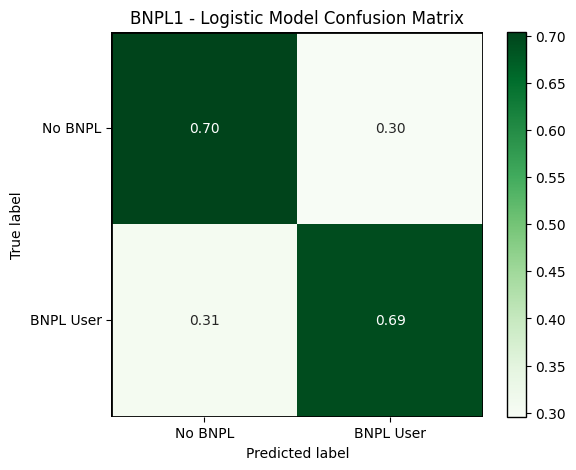

In [88]:

cm_logistic_BNPL1 = confusion_matrix(y_test, y_pred, normalize='true')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

# 1. Create the heatmap WITHOUT internal linewidths
ax = sns.heatmap(
    cm_logistic_BNPL1,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['No BNPL', 'BNPL User'],
    yticklabels=['No BNPL', 'BNPL User']
)

plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL1 - Logistic Model Confusion Matrix")
plt.show()

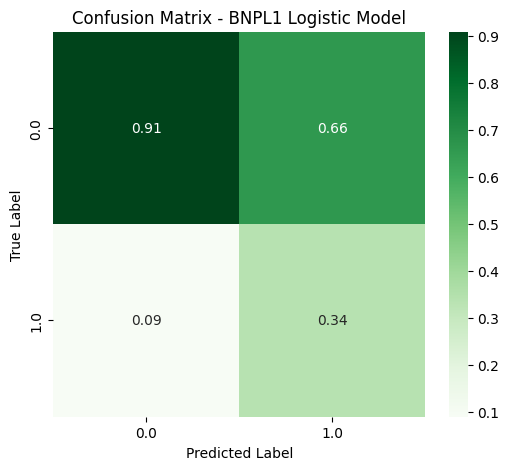

In [104]:
# cm
cm_logistic_BNPL1 = confusion_matrix(y_test, y_pred, normalize='pred')

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic_BNPL1,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL1 Logistic Model")
plt.show()


## BNPL3

### Data preprocessing

In [105]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/tmp/ipykernel_44926/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [106]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL3']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [107]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [108]:
# drop columns
data_cleaned = data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                                  'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])

In [109]:
data_cleaned = data_cleaned.dropna()

In [110]:
# independent variables
X = data_cleaned.drop(columns=['BNPL3'])
# target variable
y = data_cleaned['BNPL3']

# weights
weights = data_cleaned['weight']

In [111]:
# train, test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# resampling train fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test_res = X_test["weight"].values
X_test_res = X_test.drop(columns=["weight"])


In [112]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017"]

scaler = StandardScaler()

X_train_res[numeric_cols] = scaler.fit_transform(X_train_res[numeric_cols])
X_test_res[numeric_cols] = scaler.transform(X_test_res[numeric_cols])

### Build model

In [113]:
# build model
log_reg_cv = LogisticRegressionCV(
    Cs=10, # try 10 different penalty values
    cv=5,
    penalty='l2',
    scoring='roc_auc',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

# fit the model
log_reg_cv.fit(X_train_res, y_train_res)

# display model result with different penalty scores
print(f"Optimal C (Regularization Strength): {log_reg_cv.C_[0]}")

Optimal C (Regularization Strength): 2.782559402207126


In [114]:
# rerun model with optimal regularization strength
final_model = LogisticRegression(
    C=2.7825,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

In [115]:
cv_scores = cross_val_score(
    final_model,
    X_train_res,
    y_train_res,
    cv=5,
    scoring='roc_auc'
)

In [116]:
# fit the mdoel and predict using test set
final_model.fit(X_train_res, y_train_res)
y_pred = final_model.predict(X_test_res)
y_proba = final_model.predict_proba(X_test_res)[:, 1]

### Report test result

In [117]:
auc_score = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC Score: {auc_score:.4f}")

Test ROC-AUC Score: 0.7550


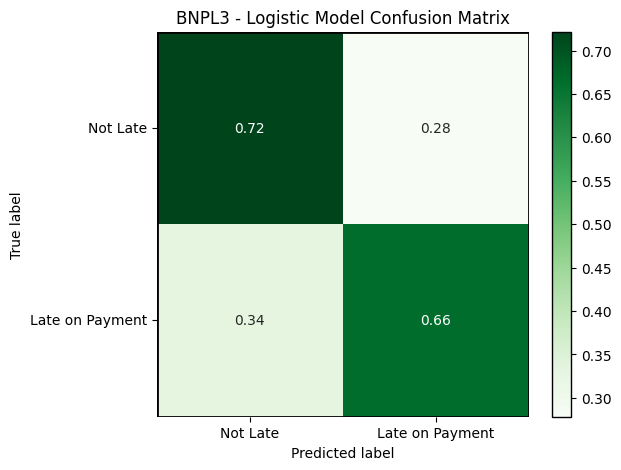

In [122]:

cm_logistic_BNPL3 = confusion_matrix(y_test, y_pred, normalize='true')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    cm_logistic_BNPL3,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=['Not Late', 'Late on Payment'],
    yticklabels=['Not Late', 'Late on Payment']
)
plt.yticks(rotation=0)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', lw=2))

cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BNPL3 - Logistic Model Confusion Matrix")
plt.show()

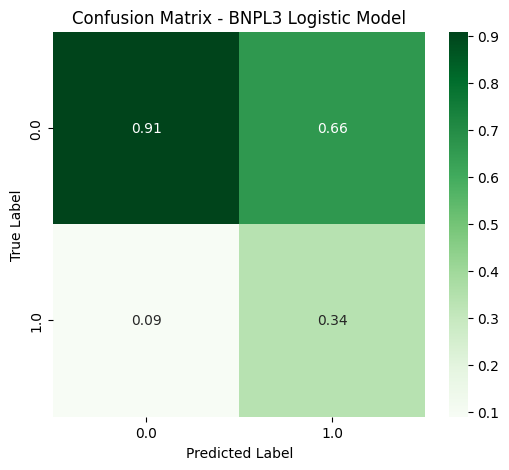

In [120]:
# cm
cm_logistic_BNPL3 = confusion_matrix(y_test, y_pred, normalize='pred')

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic_BNPL3,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL3 Logistic Model")
plt.show()
